# Phase 3B Statistical Baseline: Synthetic Rating Data

This notebook generates synthetic data for the final online music-listening study design. It is for pipeline testing, model debugging, effect-recovery testing, and later power and sample-size simulations.

The outputs are simulated data, not empirical findings. They do not indicate which real mixes participants will prefer, and they must not be interpreted as evidence about perceptual properties of the final stimuli.

## 1. Imports, Versions, and Reproducibility

The notebook uses a deterministic seed and only fits no statistical model at this stage. Bambi, PyMC, and ArviZ versions are reported when installed so the environment can be checked before the next modelling notebook.

In [1]:
from __future__ import annotations

import importlib
import importlib.metadata as metadata
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

def package_version(package_name: str) -> str:
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return "not installed in this execution environment"

version_report = pd.DataFrame(
    [
        {"component": "Python", "version": sys.version.split()[0]},
        {"component": "NumPy", "version": np.__version__},
        {"component": "pandas", "version": pd.__version__},
        {"component": "matplotlib", "version": package_version("matplotlib")},
        {"component": "ArviZ", "version": package_version("arviz")},
        {"component": "PyMC", "version": package_version("pymc")},
        {"component": "Bambi", "version": package_version("bambi")},
    ]
)

display(version_report)
print(f"Deterministic random seed: {SEED}")

,component,version
0,Python,3.10.14
1,NumPy,2.2.5
2,pandas,2.3.3
3,matplotlib,3.10.9
4,ArviZ,not installed in this execution environment
5,PyMC,not installed in this execution environment
6,Bambi,not installed in this execution environment


Deterministic random seed: 42


## 2. Repository-Relative Paths

Outputs are written relative to the repository root rather than relative to the notebook launch directory. This keeps the notebook portable across Jupyter working-directory choices.

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "stimulus_selection.yaml").exists() and (candidate / "README.md").exists():
            return candidate
    return start

REPO_ROOT = find_repo_root()
SYNTHETIC_OUTPUT_DIR = REPO_ROOT / "data" / "processed" / "synthetic" / "statistical_baseline"
SYNTHETIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repository root: {REPO_ROOT}")
print(f"Synthetic output directory: {SYNTHETIC_OUTPUT_DIR}")

Repository root: C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1. Master Program\3. MSc Project\intent2control-dissertation
Synthetic output directory: C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1. Master Program\3. MSc Project\intent2control-dissertation\data\processed\synthetic\statistical_baseline


## 3. Final Study Structure

The final design has two participant groups. Each group hears two non-overlapping songs. For every participant-song-episode trial, the participant rates all three neutral mix versions and provides a mandatory qualitative comment.

In [3]:
N_PARTICIPANTS = 40
EPISODES = [
    "Relaxation",
    "Distraction",
    "Enjoyment",
    "Focus",
    "Motivation",
]
MIXES = ["Mix_1", "Mix_2", "Mix_3"]
GROUP_SONGS = {
    "Group_1": ["Song_1", "Song_2"],
    "Group_2": ["Song_3", "Song_4"],
}
SONG_SOURCE_LABELS = {
    "Song_1": "Lead Me",
    "Song_2": "Red To Blue",
    "Song_3": "In The Meantime",
    "Song_4": "Pouring Room",
}
GROUP_SOURCE_LABELS = {
    "Group_1": "group_01 / Group A",
    "Group_2": "group_02 / Group B",
}
EXPECTED_ROWS = N_PARTICIPANTS * 2 * len(EPISODES) * len(MIXES)
EXPECTED_TRIALS = N_PARTICIPANTS * 2 * len(EPISODES)
EXPECTED_RATINGS_PER_PARTICIPANT = 2 * len(EPISODES) * len(MIXES)

study_structure = pd.DataFrame(
    [
        {"group": group, "source_group_label": GROUP_SOURCE_LABELS[group], "song_id": song, "source_song_label": SONG_SOURCE_LABELS[song]}
        for group, songs in GROUP_SONGS.items()
        for song in songs
    ]
)

display(study_structure)
print(f"Expected rating observations: {EXPECTED_ROWS}")
print(f"Expected trial-level preferences: {EXPECTED_TRIALS}")
print(f"Expected ratings per participant: {EXPECTED_RATINGS_PER_PARTICIPANT}")

,group,source_group_label,song_id,source_song_label
0,Group_1,group_01 / Group A,Song_1,Lead Me
1,Group_1,group_01 / Group A,Song_2,Red To Blue
2,Group_2,group_02 / Group B,Song_3,In The Meantime
3,Group_2,group_02 / Group B,Song_4,Pouring Room


Expected rating observations: 1200
Expected trial-level preferences: 400
Expected ratings per participant: 30


## 4. Stimulus Metadata

Neutral `song_id`, `mix_id`, and `stimulus_id` values are used in the synthetic ratings. Researcher-facing source labels are retained only for traceability.

Existing Stage 3 and Stage 4 outputs contain real Diff-MST feature rows. Four scalar descriptors can be joined clearly for the final selected mixes: RMS, crest factor, stereo width, and stereo imbalance. The Bark spectrum (`BS`) is stored in the repository as a 48-column mid/side vector, not as one clearly defined scalar. The requested `bs` metadata field is therefore left as `NaN` until a dissertation-level scalar representation is explicitly chosen.

In [4]:
FEATURE_SOURCE_CANDIDATES = [
    REPO_ROOT / "outputs" / "stimulus_selection" / "03_feature_extraction" / "tables" / "raw_diffmst_features.csv",
    REPO_ROOT / "outputs" / "stimulus_selection" / "03_feature_extraction" / "tables" / "feature_schema.json",
    REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection" / "tables" / "processed_features.csv",
    REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection" / "tables" / "bark_pca_scores.csv",
    REPO_ROOT / "outputs" / "stimulus_selection" / "04_mix_selection" / "tables" / "final_mix_selection_summary.csv",
    REPO_ROOT / "outputs" / "stimulus_selection" / "06_final_summaries" / "final_selected_mixes.csv",
]

mst_metric_files = pd.DataFrame(
    [
        {"path": str(path.relative_to(REPO_ROOT)), "exists": path.exists()}
        for path in FEATURE_SOURCE_CANDIDATES
    ]
)
display(mst_metric_files)

,path,exists
0,outputs\stimulus_selection\03_feature_extracti...,True
1,outputs\stimulus_selection\03_feature_extracti...,True
2,outputs\stimulus_selection\04_mix_selection\ta...,True
3,outputs\stimulus_selection\04_mix_selection\ta...,True
4,outputs\stimulus_selection\04_mix_selection\ta...,True
5,outputs\stimulus_selection\06_final_summaries\...,True


In [5]:
FINAL_SELECTED_MIXES_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "06_final_summaries" / "final_selected_mixes.csv"
RAW_DIFFMST_FEATURES_PATH = REPO_ROOT / "outputs" / "stimulus_selection" / "03_feature_extraction" / "tables" / "raw_diffmst_features.csv"

source_song_to_song_id = {source: song_id for song_id, source in SONG_SOURCE_LABELS.items()}
role_to_mix_id = {"representative": "Mix_1", "contrast_1": "Mix_2", "contrast_2": "Mix_3"}

if FINAL_SELECTED_MIXES_PATH.exists() and RAW_DIFFMST_FEATURES_PATH.exists():
    final_selected_mixes = pd.read_csv(FINAL_SELECTED_MIXES_PATH)
    raw_diffmst_features = pd.read_csv(RAW_DIFFMST_FEATURES_PATH)

    feature_columns = ["mix_id", "rms_mean", "crest_factor_mean", "stereo_width", "stereo_imbalance"]
    selected_with_features = final_selected_mixes.merge(
        raw_diffmst_features[feature_columns],
        on="mix_id",
        how="left",
        validate="one_to_one",
    )

    stimulus_metadata = (
        selected_with_features
        .assign(
            song_id=lambda df: df["song"].map(source_song_to_song_id),
            mix_id_neutral=lambda df: df["analytical_role"].map(role_to_mix_id),
            stimulus_id=lambda df: df["song_id"] + "_" + df["mix_id_neutral"],
            rms=lambda df: df["rms_mean"],
            cf=lambda df: df["crest_factor_mean"],
            bs=np.nan,
            sw=lambda df: df["stereo_width"],
            si=lambda df: df["stereo_imbalance"],
            bs_note="Bark spectrum exists as bark_mid_01..24 and bark_side_01..24 in raw_diffmst_features.csv; no one-column BS scalar is assumed here.",
        )
        .rename(columns={"mix_id": "source_mix_id", "mix_id_neutral": "mix_id"})
        [[
            "song_id", "mix_id", "stimulus_id", "rms", "cf", "bs", "sw", "si",
            "source_mix_id", "song", "analytical_role", "original_mix_name", "original_dataset_filename", "bs_note",
        ]]
        .sort_values(["song_id", "mix_id"])
        .reset_index(drop=True)
    )
else:
    stimulus_metadata = pd.DataFrame(
        [
            {
                "song_id": song_id,
                "mix_id": mix_id,
                "stimulus_id": f"{song_id}_{mix_id}",
                "rms": np.nan,
                "cf": np.nan,
                "bs": np.nan,
                "sw": np.nan,
                "si": np.nan,
                "source_mix_id": pd.NA,
                "song": SONG_SOURCE_LABELS[song_id],
                "analytical_role": pd.NA,
                "original_mix_name": pd.NA,
                "original_dataset_filename": pd.NA,
                "bs_note": "Placeholder: real MST feature source not found.",
            }
            for song_id in SONG_SOURCE_LABELS
            for mix_id in MIXES
        ]
    )

required_metadata_columns = ["song_id", "mix_id", "stimulus_id", "rms", "cf", "bs", "sw", "si"]
assert stimulus_metadata[required_metadata_columns].shape == (12, 8)
assert stimulus_metadata["stimulus_id"].is_unique
assert stimulus_metadata.groupby("song_id")["mix_id"].nunique().eq(3).all()

display(stimulus_metadata[required_metadata_columns + ["source_mix_id", "song", "original_mix_name"]])

,song_id,mix_id,stimulus_id,rms,cf,bs,sw,si,source_mix_id,song,original_mix_name
0,Song_1,Mix_1,Song_1_Mix_1,0.065696,18.580093,NaN,0.074083,-0.024806,mix_9346b5d4ade2,Lead Me,McG-A
1,Song_1,Mix_2,Song_1_Mix_2,0.059133,16.919521,NaN,0.017093,-0.012909,mix_d5b28dfc8a93,Lead Me,PXL-L1
2,Song_1,Mix_3,Song_1_Mix_3,0.062587,13.814332,NaN,0.117577,-0.052133,mix_f1f7973e5bac,Lead Me,DU-D
3,Song_2,Mix_1,Song_2_Mix_1,0.052310,15.712576,NaN,0.054548,0.026530,mix_e2654ec905ad,Red To Blue,McG-A
4,Song_2,Mix_2,Song_2_Mix_2,0.045474,17.619415,NaN,0.134229,0.126785,mix_7ac13e0b6376,Red To Blue,McG-B
5,Song_2,Mix_3,Song_2_Mix_3,0.048100,14.425890,NaN,0.249742,0.099542,mix_dcc6aef84d67,Red To Blue,McG-F
6,Song_3,Mix_1,Song_3_Mix_1,0.055188,16.992939,NaN,0.090187,-0.018254,mix_efdedc0a36e7,In The Meantime,UCP-A4
7,Song_3,Mix_2,Song_3_Mix_2,0.052479,18.226074,NaN,0.220763,0.595546,mix_22efc79c8253,In The Meantime,DU-J
8,Song_3,Mix_3,Song_3_Mix_3,0.056029,17.366356,NaN,0.000544,0.000563,mix_c7bdcba64775,In The Meantime,QUT-B
9,Song_4,Mix_1,Song_4_Mix_1,0.059299,18.820015,NaN,0.193890,0.056255,mix_0ddb25d6180b,Pouring Room,McG-Q


## 5. Simulation Assumptions for Effect-Recovery Testing

The following parameters are deliberately hypothetical. They create a recoverable Episode x Mix interaction using neutral mix identifiers only. These values are simulation assumptions, not observed effects and not perceptual interpretations of the real stimuli.

In [6]:
GRAND_MEAN = 65.0

EPISODE_EFFECTS = {
    "Relaxation": 0.0,
    "Distraction": -2.0,
    "Enjoyment": 3.0,
    "Focus": 1.0,
    "Motivation": 2.0,
}

MIX_EFFECTS = {
    "Mix_1": 0.0,
    "Mix_2": 1.0,
    "Mix_3": 1.0,
}

INTERACTION_EFFECTS = {
    ("Relaxation", "Mix_1"): 4.0,
    ("Relaxation", "Mix_2"): 2.0,
    ("Relaxation", "Mix_3"): -3.0,
    ("Distraction", "Mix_1"): 2.0,
    ("Distraction", "Mix_2"): 3.0,
    ("Distraction", "Mix_3"): -2.0,
    ("Enjoyment", "Mix_1"): 0.0,
    ("Enjoyment", "Mix_2"): 3.0,
    ("Enjoyment", "Mix_3"): 2.0,
    ("Focus", "Mix_1"): 3.0,
    ("Focus", "Mix_2"): 4.0,
    ("Focus", "Mix_3"): -3.0,
    ("Motivation", "Mix_1"): -3.0,
    ("Motivation", "Mix_2"): 0.0,
    ("Motivation", "Mix_3"): 6.0,
}

simulation_effect_table = pd.DataFrame(
    [
        {
            "episode": episode,
            "mix_id": mix_id,
            "episode_effect": EPISODE_EFFECTS[episode],
            "mix_effect": MIX_EFFECTS[mix_id],
            "episode_mix_interaction": INTERACTION_EFFECTS[(episode, mix_id)],
        }
        for episode in EPISODES
        for mix_id in MIXES
    ]
)

display(simulation_effect_table)

,episode,mix_id,episode_effect,mix_effect,episode_mix_interaction
0,Relaxation,Mix_1,0.0,0.0,4.0
1,Relaxation,Mix_2,0.0,1.0,2.0
2,Relaxation,Mix_3,0.0,1.0,-3.0
3,Distraction,Mix_1,-2.0,0.0,2.0
4,Distraction,Mix_2,-2.0,1.0,3.0
5,Distraction,Mix_3,-2.0,1.0,-2.0
6,Enjoyment,Mix_1,3.0,0.0,0.0
7,Enjoyment,Mix_2,3.0,1.0,3.0
8,Enjoyment,Mix_3,3.0,1.0,2.0
9,Focus,Mix_1,1.0,0.0,3.0


## 6. Variability Assumptions

These standard deviations control participant, song, and residual variability in the synthetic data. They are assumptions for stress-testing the analysis pipeline.

In [7]:
PARTICIPANT_SD = 8.0
PARTICIPANT_MIX_SD = 4.0
SONG_SD = 3.0
RESIDUAL_SD = 9.0

variability_assumptions = pd.DataFrame(
    [
        {"parameter": "PARTICIPANT_SD", "value": PARTICIPANT_SD, "description": "general participant rating tendency"},
        {"parameter": "PARTICIPANT_MIX_SD", "value": PARTICIPANT_MIX_SD, "description": "participant-specific deviations for neutral mix IDs"},
        {"parameter": "SONG_SD", "value": SONG_SD, "description": "song-level baseline differences"},
        {"parameter": "RESIDUAL_SD", "value": RESIDUAL_SD, "description": "rating-level residual noise"},
    ]
)

display(variability_assumptions)

,parameter,value,description
0,PARTICIPANT_SD,8.0,general participant rating tendency
1,PARTICIPANT_MIX_SD,4.0,participant-specific deviations for neutral mi...
2,SONG_SD,3.0,song-level baseline differences
3,RESIDUAL_SD,9.0,rating-level residual noise


## 7. Participant Assignment and Random Effects

Participants are split evenly across the two non-overlapping song groups. Random effects are simulated after group assignment so the generated dataset is deterministic for the chosen seed.

In [8]:
participant_ids = [f"P{i:03d}" for i in range(1, N_PARTICIPANTS + 1)]
participant_groups = {
    participant_id: "Group_1" if index < N_PARTICIPANTS / 2 else "Group_2"
    for index, participant_id in enumerate(participant_ids)
}

participant_intercepts = {
    participant_id: rng.normal(0, PARTICIPANT_SD)
    for participant_id in participant_ids
}
participant_mix_effects = {
    participant_id: {mix_id: rng.normal(0, PARTICIPANT_MIX_SD) for mix_id in MIXES}
    for participant_id in participant_ids
}
song_intercepts = {
    song_id: rng.normal(0, SONG_SD)
    for songs in GROUP_SONGS.values()
    for song_id in songs
}

participant_assignment = pd.DataFrame(
    [{"participant_id": participant_id, "group": group} for participant_id, group in participant_groups.items()]
)

display(participant_assignment.groupby("group").size().rename("participants").reset_index())

,group,participants
0,Group_1,20
1,Group_2,20


## 8. Generate Rating-Level Synthetic Data

Each participant rates three neutral mixes for each assigned song across five listening episodes. The `comment` column is populated to mimic the mandatory qualitative response field.

In [9]:
stimulus_lookup = stimulus_metadata.set_index(["song_id", "mix_id"])
rows = []

for participant_id in participant_ids:
    group = participant_groups[participant_id]
    assigned_songs = GROUP_SONGS[group]

    for song_id in assigned_songs:
        for episode in EPISODES:
            mix_order = rng.permutation(MIXES)

            for presentation_order, mix_id in enumerate(mix_order, start=1):
                stimulus_id = stimulus_lookup.loc[(song_id, mix_id), "stimulus_id"]
                expected_rating = (
                    GRAND_MEAN
                    + EPISODE_EFFECTS[episode]
                    + MIX_EFFECTS[mix_id]
                    + INTERACTION_EFFECTS[(episode, mix_id)]
                    + participant_intercepts[participant_id]
                    + participant_mix_effects[participant_id][mix_id]
                    + song_intercepts[song_id]
                )
                observed_rating = np.clip(rng.normal(expected_rating, RESIDUAL_SD), 0, 100)

                rows.append(
                    {
                        "participant_id": participant_id,
                        "group": group,
                        "song_id": song_id,
                        "mix_id": mix_id,
                        "stimulus_id": stimulus_id,
                        "episode": episode,
                        "presentation_order": presentation_order,
                        "expected_rating": round(expected_rating, 3),
                        "rating": round(observed_rating, 1),
                        "comment": f"Synthetic mandatory comment for {stimulus_id} during {episode}.",
                    }
                )

ratings_df = pd.DataFrame(rows)
ratings_df = ratings_df[
    [
        "participant_id", "group", "song_id", "mix_id", "stimulus_id", "episode",
        "presentation_order", "expected_rating", "rating", "comment",
    ]
]

display(ratings_df.head(10))

,participant_id,group,song_id,mix_id,stimulus_id,episode,presentation_order,expected_rating,rating,comment
0,P001,Group_1,Song_1,Mix_1,Song_1_Mix_1,Relaxation,1,71.515,63.4,Synthetic mandatory comment for Song_1_Mix_1 d...
1,P001,Group_1,Song_1,Mix_3,Song_1_Mix_3,Relaxation,2,59.880,68.3,Synthetic mandatory comment for Song_1_Mix_3 d...
2,P001,Group_1,Song_1,Mix_2,Song_1_Mix_2,Relaxation,3,69.715,73.2,Synthetic mandatory comment for Song_1_Mix_2 d...
3,P001,Group_1,Song_1,Mix_1,Song_1_Mix_1,Distraction,1,67.515,67.1,Synthetic mandatory comment for Song_1_Mix_1 d...
4,P001,Group_1,Song_1,Mix_3,Song_1_Mix_3,Distraction,2,58.880,53.0,Synthetic mandatory comment for Song_1_Mix_3 d...
5,P001,Group_1,Song_1,Mix_2,Song_1_Mix_2,Distraction,3,68.715,72.7,Synthetic mandatory comment for Song_1_Mix_2 d...
6,P001,Group_1,Song_1,Mix_3,Song_1_Mix_3,Enjoyment,1,67.880,56.8,Synthetic mandatory comment for Song_1_Mix_3 d...
7,P001,Group_1,Song_1,Mix_2,Song_1_Mix_2,Enjoyment,2,73.715,62.2,Synthetic mandatory comment for Song_1_Mix_2 d...
8,P001,Group_1,Song_1,Mix_1,Song_1_Mix_1,Enjoyment,3,70.515,72.1,Synthetic mandatory comment for Song_1_Mix_1 d...
9,P001,Group_1,Song_1,Mix_1,Song_1_Mix_1,Focus,1,71.515,73.0,Synthetic mandatory comment for Song_1_Mix_1 d...


## 9. Validate Rating-Level Structure

The checks below confirm that the synthetic data preserves the final design: 30 ratings per participant, two songs per participant, three mixes per participant-song-episode trial, correct group-song assignment, bounded ratings, and non-null comments.

In [10]:
trial_columns = ["participant_id", "group", "song_id", "episode"]

validation_results = []

def add_check(check: str, passed: bool, observed: object, expected: object) -> None:
    validation_results.append(
        {"check": check, "passed": bool(passed), "observed": observed, "expected": expected}
    )

add_check("expected_number_of_rows", len(ratings_df) == EXPECTED_ROWS, len(ratings_df), EXPECTED_ROWS)
add_check(
    "exactly_30_ratings_per_participant",
    ratings_df.groupby("participant_id").size().eq(EXPECTED_RATINGS_PER_PARTICIPANT).all(),
    ratings_df.groupby("participant_id").size().unique().tolist(),
    EXPECTED_RATINGS_PER_PARTICIPANT,
)
add_check(
    "exactly_2_songs_per_participant",
    ratings_df.groupby("participant_id")["song_id"].nunique().eq(2).all(),
    ratings_df.groupby("participant_id")["song_id"].nunique().unique().tolist(),
    2,
)
add_check(
    "exactly_3_mixes_per_trial",
    ratings_df.groupby(trial_columns)["mix_id"].nunique().eq(3).all(),
    ratings_df.groupby(trial_columns)["mix_id"].nunique().unique().tolist(),
    3,
)
add_check(
    "group_song_assignments_correct",
    ratings_df.groupby("group")["song_id"].apply(lambda s: sorted(s.unique().tolist())).to_dict() == {g: songs for g, songs in GROUP_SONGS.items()},
    ratings_df.groupby("group")["song_id"].apply(lambda s: sorted(s.unique().tolist())).to_dict(),
    GROUP_SONGS,
)
add_check("ratings_between_0_and_100", ratings_df["rating"].between(0, 100).all(), "all within bounds", "0 <= rating <= 100")
add_check("mandatory_comments_non_null", ratings_df["comment"].notna().all() and ratings_df["comment"].str.strip().ne("").all(), "all present", "non-null and non-empty")
add_check("presentation_order_is_1_to_3", ratings_df.groupby(trial_columns)["presentation_order"].apply(lambda s: sorted(s.tolist()) == [1, 2, 3]).all(), "all trials checked", "[1, 2, 3]")

validation_df = pd.DataFrame(validation_results)
display(validation_df)
assert validation_df["passed"].all()

,check,passed,observed,expected
0,expected_number_of_rows,True,1200,1200
1,exactly_30_ratings_per_participant,True,[30],30
2,exactly_2_songs_per_participant,True,[2],2
3,exactly_3_mixes_per_trial,True,[3],3
4,group_song_assignments_correct,True,"{'Group_1': ['Song_1', 'Song_2'], 'Group_2': [...","{'Group_1': ['Song_1', 'Song_2'], 'Group_2': [..."
5,ratings_between_0_and_100,True,all within bounds,0 <= rating <= 100
6,mandatory_comments_non_null,True,all present,non-null and non-empty
7,presentation_order_is_1_to_3,True,all trials checked,"[1, 2, 3]"


## 10. Derive Trial-Level Preferences and Ties

For each participant-song-episode trial, the rating-based preference is the mix or mixes with the highest rating. Equal maximum ratings are retained as ties. Tied winners are represented in a single trial-level row as a pipe-delimited list, with an optional long-format tie table for direct counting.

In [11]:
trial_max = ratings_df.groupby(trial_columns, as_index=False)["rating"].max().rename(columns={"rating": "highest_rating"})
winner_rows = ratings_df.merge(trial_max, on=trial_columns, how="inner")
winner_rows = winner_rows[winner_rows["rating"].eq(winner_rows["highest_rating"])].copy()

preference_df = (
    winner_rows
    .sort_values(trial_columns + ["mix_id"])
    .groupby(trial_columns, as_index=False)
    .agg(
        highest_rating=("highest_rating", "first"),
        highest_rated_mix=("mix_id", lambda values: "|".join(values)),
        number_of_joint_winners=("mix_id", "size"),
    )
)
preference_df["is_tie"] = preference_df["number_of_joint_winners"].gt(1)
preference_df = preference_df[
    ["participant_id", "group", "song_id", "episode", "highest_rating", "highest_rated_mix", "is_tie"]
]

tie_long_df = winner_rows.loc[
    winner_rows.duplicated(trial_columns, keep=False),
    trial_columns + ["mix_id", "stimulus_id", "rating"],
].rename(columns={"mix_id": "joint_highest_rated_mix"}).reset_index(drop=True)

preference_validation = pd.DataFrame(
    [
        {"check": "one_preference_row_per_trial", "passed": len(preference_df) == EXPECTED_TRIALS, "observed": len(preference_df), "expected": EXPECTED_TRIALS},
        {"check": "all_trials_unique", "passed": not preference_df.duplicated(trial_columns).any(), "observed": int(preference_df.duplicated(trial_columns).sum()), "expected": 0},
        {"check": "unique_or_explicit_tie", "passed": preference_df["highest_rated_mix"].notna().all() and preference_df["is_tie"].isin([True, False]).all(), "observed": "all rows labelled", "expected": "winner list plus tie flag"},
    ]
)

display(preference_df.head(10))
display(preference_validation)
assert preference_validation["passed"].all()

,participant_id,group,song_id,episode,highest_rating,highest_rated_mix,is_tie
0,P001,Group_1,Song_1,Distraction,72.7,Mix_2,False
1,P001,Group_1,Song_1,Enjoyment,72.1,Mix_1,False
2,P001,Group_1,Song_1,Focus,75.3,Mix_2,False
3,P001,Group_1,Song_1,Motivation,79.7,Mix_2,False
4,P001,Group_1,Song_1,Relaxation,73.2,Mix_2,False
5,P001,Group_1,Song_2,Distraction,83.7,Mix_1,False
6,P001,Group_1,Song_2,Enjoyment,80.2,Mix_2,False
7,P001,Group_1,Song_2,Focus,76.5,Mix_2,False
8,P001,Group_1,Song_2,Motivation,73.0,Mix_1,False
9,P001,Group_1,Song_2,Relaxation,74.4,Mix_3,False


,check,passed,observed,expected
0,one_preference_row_per_trial,True,400,400
1,all_trials_unique,True,0,0
2,unique_or_explicit_tie,True,all rows labelled,winner list plus tie flag


## 11. Participant and Observation Counts

These summaries are quick balance checks for the simulated participant allocation and the resulting rating table.

In [12]:
participant_counts = ratings_df.groupby("group")["participant_id"].nunique().rename("participants").reset_index()
observation_counts = ratings_df.groupby("group").size().rename("rating_observations").reset_index()
trial_counts = preference_df.groupby("group").size().rename("song_episode_trials").reset_index()
count_summary = participant_counts.merge(observation_counts, on="group").merge(trial_counts, on="group")

display(count_summary)

,group,participants,rating_observations,song_episode_trials
0,Group_1,20,600,200
1,Group_2,20,600,200


## 12. Group and Song Balance Checks

The synthetic data should retain the non-overlapping song design: `Group_1` has `Song_1` and `Song_2`, while `Group_2` has `Song_3` and `Song_4`.

In [13]:
group_song_balance = (
    ratings_df
    .groupby(["group", "song_id"])
    .agg(participants=("participant_id", "nunique"), rating_observations=("rating", "size"))
    .reset_index()
)

display(group_song_balance)

,group,song_id,participants,rating_observations
0,Group_1,Song_1,20,300
1,Group_1,Song_2,20,300
2,Group_2,Song_3,20,300
3,Group_2,Song_4,20,300


## 13. Ratings by Episode and Mix

This table is useful for spotting obvious simulation errors before any modelling is attempted.

In [14]:
ratings_by_episode_mix = (
    ratings_df
    .groupby(["episode", "mix_id"])["rating"]
    .agg(count="count", mean="mean", std="std", minimum="min", maximum="max")
    .round(2)
    .reset_index()
)

display(ratings_by_episode_mix)

,episode,mix_id,count,mean,std,minimum,maximum
0,Distraction,Mix_1,80,64.28,12.31,31.5,89.2
1,Distraction,Mix_2,80,65.63,12.22,32.9,88.9
2,Distraction,Mix_3,80,61.08,13.78,30.0,94.0
3,Enjoyment,Mix_1,80,65.70,12.73,39.4,100.0
4,Enjoyment,Mix_2,80,71.13,11.88,47.9,100.0
5,Enjoyment,Mix_3,80,69.25,12.17,42.1,100.0
6,Focus,Mix_1,80,69.94,13.70,38.7,100.0
7,Focus,Mix_2,80,70.76,12.43,43.0,97.8
8,Focus,Mix_3,80,63.28,12.77,32.9,99.0
9,Motivation,Mix_1,80,63.06,11.74,27.3,87.9


## 14. Rating Distribution

The histogram checks that the generated ratings occupy a plausible range on the 0-100 scale without implying empirical participant behaviour.

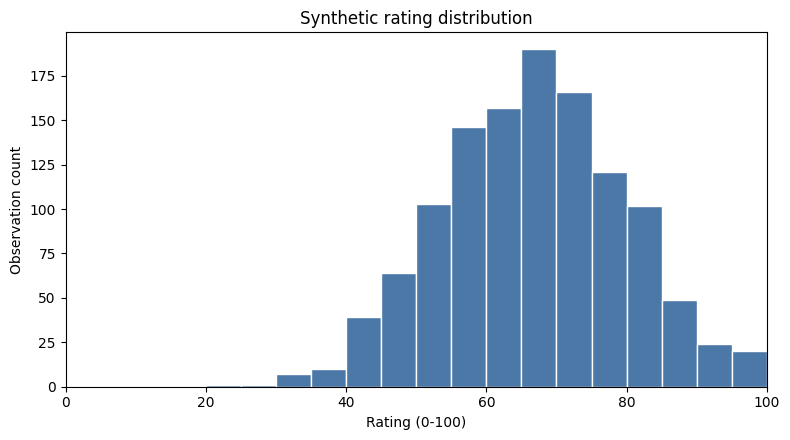

,rating
count,1200.00
mean,66.73
std,12.98
min,23.20
25%,57.80
50%,66.50
75%,75.50
max,100.00


In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(ratings_df["rating"], bins=np.arange(0, 105, 5), color="#4C78A8", edgecolor="white")
ax.set_title("Synthetic rating distribution")
ax.set_xlabel("Rating (0-100)")
ax.set_ylabel("Observation count")
ax.set_xlim(0, 100)
fig.tight_layout()
plt.show()

rating_distribution_summary = ratings_df["rating"].describe().round(2).to_frame(name="rating")
display(rating_distribution_summary)

## 15. Mean Rating by Episode and Mix

The plot visualises the simulated Episode x Mix pattern for effect-recovery testing only.

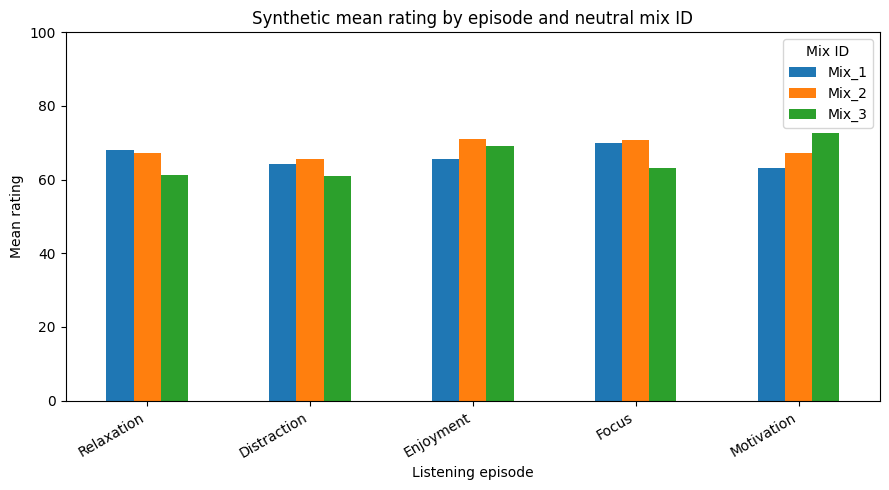

mix_id,Mix_1,Mix_2,Mix_3
episode,,,
Relaxation,68.13,67.31,61.32
Distraction,64.28,65.63,61.08
Enjoyment,65.70,71.13,69.25
Focus,69.94,70.76,63.28
Motivation,63.06,67.37,72.77


In [16]:
mean_rating_matrix = (
    ratings_df
    .groupby(["episode", "mix_id"])["rating"]
    .mean()
    .unstack("mix_id")
    .loc[EPISODES, MIXES]
)

fig, ax = plt.subplots(figsize=(9, 5))
mean_rating_matrix.plot(kind="bar", ax=ax)
ax.set_title("Synthetic mean rating by episode and neutral mix ID")
ax.set_xlabel("Listening episode")
ax.set_ylabel("Mean rating")
ax.set_ylim(0, 100)
ax.legend(title="Mix ID")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
plt.show()

display(mean_rating_matrix.round(2))

## 16. Derived Preference Counts and Tie Frequency

Preference counts are derived from ratings only. Ties are retained rather than randomly broken.

In [17]:
preference_counts = (
    preference_df
    .assign(highest_rated_mix=preference_df["highest_rated_mix"].str.split("|"))
    .explode("highest_rated_mix")
    .groupby(["episode", "highest_rated_mix"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=EPISODES, columns=MIXES, fill_value=0)
)

tie_frequency = pd.DataFrame(
    [
        {"measure": "trial_count", "value": len(preference_df)},
        {"measure": "tied_trial_count", "value": int(preference_df["is_tie"].sum())},
        {"measure": "tied_trial_percentage", "value": round(float(preference_df["is_tie"].mean() * 100), 2)},
        {"measure": "long_format_joint_winner_rows", "value": len(tie_long_df)},
    ]
)

display(preference_counts)
display(tie_frequency)

highest_rated_mix,Mix_1,Mix_2,Mix_3
episode,,,
Relaxation,33,29,18
Distraction,29,35,17
Enjoyment,18,37,26
Focus,28,36,16
Motivation,10,27,43


,measure,value
0,trial_count,400.0
1,tied_trial_count,2.0
2,tied_trial_percentage,0.5
3,long_format_joint_winner_rows,4.0


## 17. Export Synthetic Outputs

The exported CSV files are for downstream pipeline tests and future modelling notebooks. They are synthetic and should not be reported as observed participant results.

In [18]:
ratings_path = SYNTHETIC_OUTPUT_DIR / "synthetic_ratings_seed42.csv"
preferences_path = SYNTHETIC_OUTPUT_DIR / "synthetic_trial_preferences_seed42.csv"
ties_path = SYNTHETIC_OUTPUT_DIR / "synthetic_trial_ties_long_seed42.csv"
stimulus_metadata_path = SYNTHETIC_OUTPUT_DIR / "synthetic_stimulus_metadata_seed42.csv"
validation_path = SYNTHETIC_OUTPUT_DIR / "synthetic_validation_results_seed42.csv"

ratings_df.to_csv(ratings_path, index=False)
preference_df.to_csv(preferences_path, index=False)
tie_long_df.to_csv(ties_path, index=False)
stimulus_metadata.to_csv(stimulus_metadata_path, index=False)
validation_df.to_csv(validation_path, index=False)

export_summary = pd.DataFrame(
    [
        {"dataset": "ratings_df", "shape": str(ratings_df.shape), "path": str(ratings_path.relative_to(REPO_ROOT))},
        {"dataset": "preference_df", "shape": str(preference_df.shape), "path": str(preferences_path.relative_to(REPO_ROOT))},
        {"dataset": "tie_long_df", "shape": str(tie_long_df.shape), "path": str(ties_path.relative_to(REPO_ROOT))},
        {"dataset": "stimulus_metadata", "shape": str(stimulus_metadata.shape), "path": str(stimulus_metadata_path.relative_to(REPO_ROOT))},
        {"dataset": "validation_df", "shape": str(validation_df.shape), "path": str(validation_path.relative_to(REPO_ROOT))},
    ]
)

display(export_summary)

,dataset,shape,path
0,ratings_df,"(1200, 10)",data\processed\synthetic\statistical_baseline\...
1,preference_df,"(400, 7)",data\processed\synthetic\statistical_baseline\...
2,tie_long_df,"(4, 7)",data\processed\synthetic\statistical_baseline\...
3,stimulus_metadata,"(12, 14)",data\processed\synthetic\statistical_baseline\...
4,validation_df,"(8, 4)",data\processed\synthetic\statistical_baseline\...


## 18. Final Validation Summary

All checks must pass before this notebook's outputs are used for later model debugging or power-simulation work.

In [19]:
final_validation = pd.concat(
    [
        validation_df.assign(stage="rating_level"),
        preference_validation.assign(stage="preference_level"),
    ],
    ignore_index=True,
)

display(final_validation[["stage", "check", "passed", "observed", "expected"]])
assert final_validation["passed"].all()

print("All notebook validation checks passed.")
print(f"ratings_df shape: {ratings_df.shape}")
print(f"preference_df shape: {preference_df.shape}")
print(f"tie_long_df shape: {tie_long_df.shape}")
print(f"stimulus_metadata shape: {stimulus_metadata.shape}")

,stage,check,passed,observed,expected
0,rating_level,expected_number_of_rows,True,1200,1200
1,rating_level,exactly_30_ratings_per_participant,True,[30],30
2,rating_level,exactly_2_songs_per_participant,True,[2],2
3,rating_level,exactly_3_mixes_per_trial,True,[3],3
4,rating_level,group_song_assignments_correct,True,"{'Group_1': ['Song_1', 'Song_2'], 'Group_2': [...","{'Group_1': ['Song_1', 'Song_2'], 'Group_2': [..."
5,rating_level,ratings_between_0_and_100,True,all within bounds,0 <= rating <= 100
6,rating_level,mandatory_comments_non_null,True,all present,non-null and non-empty
7,rating_level,presentation_order_is_1_to_3,True,all trials checked,"[1, 2, 3]"
8,preference_level,one_preference_row_per_trial,True,400,400
9,preference_level,all_trials_unique,True,0,0


All notebook validation checks passed.
ratings_df shape: (1200, 10)
preference_df shape: (400, 7)
tie_long_df shape: (4, 7)
stimulus_metadata shape: (12, 14)


## 19. Limitations and Next Steps

- The rating and preference effects in this notebook are simulated rather than observed.
- The neutral mix categories may not be comparable across songs unless the underlying selected versions represent consistent profiles across songs.
- The real MST feature values must be incorporated into later analyses with a clear feature definition. The scalar RMS, CF, SW, and SI values are available for the selected mixes; BS currently exists as a multidimensional Bark spectrum rather than a single scalar in the checked repository outputs.
- Feature correlations must be inspected before deciding whether the final statistical baseline should use categorical mix labels, actual MST features, or a hybrid representation.
- The next notebook will fit the first Bambi mixed-effects model.
- The final statistical baseline may need to use the actual MST features rather than only categorical mix labels, especially if neutral mix identifiers are not consistently comparable across songs.